In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
import rasterio
from pathlib import Path
from tqdm.notebook import tqdm

## Analysis Parameters

In [4]:
# Model fit dataset
modelset = '../data/MtPleasant.pkl'

# Image save location
save_image_base = '../data/results_MtPleasant/model'
file_ext = '.svg'

## Load Models

In [5]:
models = pd.read_pickle(modelset)

## Analysis

### Greenup date

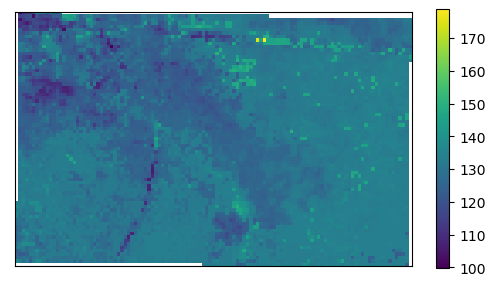

In [15]:
models = models.dropna().copy()
models['greenup'] = models['breaks'].map(lambda x: x[1])
models_pivot = models[['lat', 'lon', 'greenup']].pivot(index = 'lat', columns = 'lon')
plt.imshow(models_pivot)
plt.colorbar(shrink = 0.7)
plt.xticks([])
plt.yticks([])
plt.savefig(save_image_base + '_greenup' + file_ext, bbox_inches='tight')

### Greenrate

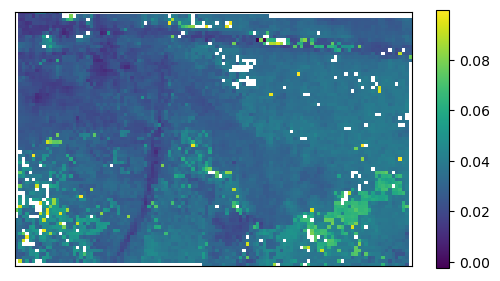

In [27]:
models = models.dropna().copy()
models['greenrate'] = models['slopes'].map(lambda x: x[1])
mask = models['greenrate'] < 0.1
models_pivot = models.loc[mask, ['lat', 'lon', 'greenrate']].pivot(index = 'lat', columns = 'lon')
plt.imshow(models_pivot)
plt.colorbar(shrink = 0.7)
plt.xticks([])
plt.yticks([])
plt.savefig(save_image_base + '_greenrate' + file_ext, bbox_inches='tight')

### Max Date

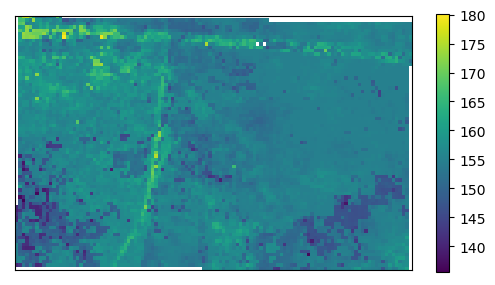

In [32]:
models = models.dropna().copy()
models['maxdate'] = models['breaks'].map(lambda x: x[2])
mask = models['maxdate'] < 200
models_pivot = models.loc[mask, ['lat', 'lon', 'maxdate']].pivot(index = 'lat', columns = 'lon')
plt.imshow(models_pivot)
plt.colorbar(shrink = 0.7)
plt.xticks([])
plt.yticks([])
plt.savefig(save_image_base + '_maxdate' + file_ext, bbox_inches='tight')

### Seasonal Decline

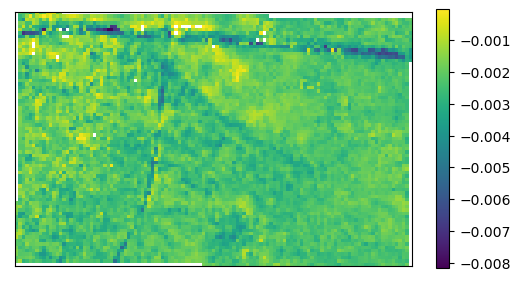

In [44]:
models = models.dropna().copy()
models['seas_decline'] = models['slopes'].map(lambda x: x[2])
mask = (models['seas_decline'] < 0) & (models['seas_decline'] > -0.010)
models_pivot = models.loc[mask, ['lat', 'lon', 'seas_decline']].pivot(index = 'lat', columns = 'lon')
plt.imshow(models_pivot)
plt.colorbar(shrink = 0.7)
plt.xticks([])
plt.yticks([])
plt.savefig(save_image_base + '_seas_decline' + file_ext, bbox_inches='tight')

### Leaf fall date

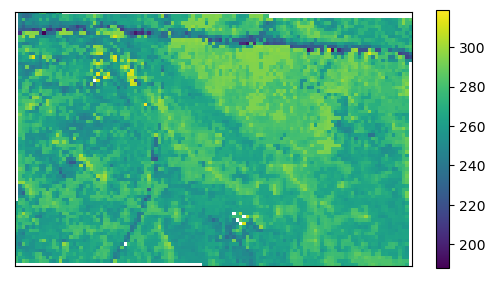

In [48]:
models = models.dropna().copy()
models['leaf_fall_date'] = models['breaks'].map(lambda x: x[3])
mask = (models['leaf_fall_date'] < 320)
models_pivot = models.loc[mask, ['lat', 'lon', 'leaf_fall_date']].pivot(index = 'lat', columns = 'lon')
plt.imshow(models_pivot)
plt.colorbar(shrink = 0.7)
plt.xticks([])
plt.yticks([])
plt.savefig(save_image_base + '_leaf_fall_date' + file_ext, bbox_inches='tight')

### Senescence

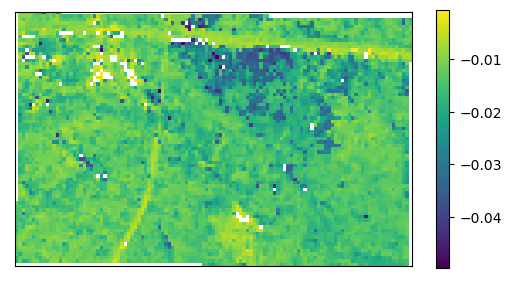

In [63]:
models = models.dropna().copy()
models['senescence'] = models['slopes'].map(lambda x: x[3])
mask = (models['senescence'] > -0.05) & (models['senescence'] < 0)
models_pivot = models.loc[mask, ['lat', 'lon', 'senescence']].pivot(index = 'lat', columns = 'lon')
plt.imshow(models_pivot)
plt.colorbar(shrink = 0.7)
plt.xticks([])
plt.yticks([])
plt.savefig(save_image_base + '_senescence' + file_ext, bbox_inches='tight')

In [37]:
models

,lat,lon,intercepts,slopes,breaks,greenup,greenrate,maxdate,seas_decline,leaf_fall_date,senescence
1,0.0,1.0,"[0.2827846766982531, -1.3843628778038928, 1.30...","[-0.002564015815519366, 0.013895424812664965, ...","[63.0, 101.28822674856914, 167.99999999961958,...",101.288227,0.013895,168.000000,-0.002118,250.000000,-0.009086
2,0.0,2.0,"[0.09459732977273905, -1.3484381078367302, 1.3...","[-7.831132301729819e-05, 0.013137937554291657,...","[63.0, 109.18646062174452, 174.99999999434493,...",109.186461,0.013138,175.000000,-0.002370,243.146492,-0.009081
3,0.0,3.0,"[0.12021124781919687, -1.4945264856542653, 1.3...","[-0.0004654420703958224, 0.013711101431490087,...","[63.0, 113.90207586628243, 177.375001497993, 2...",113.902076,0.013711,177.375001,-0.002172,237.978538,-0.009045
4,0.0,4.0,"[0.14631545647642075, -1.7263576216361263, 1.5...","[-0.0007539770266174687, 0.01568735239813789, ...","[63.0, 113.90034404960606, 171.9176106069843, ...",113.900344,0.015687,171.917611,-0.003451,246.270847,-0.008589
5,0.0,5.0,"[0.06113444873412709, -2.1944020440854466, 1.3...","[0.00014344305923626099, 0.019088854540479244,...","[63.0, 119.05450008582189, 163.00125455130402,...",119.054500,0.019089,163.001255,-0.002506,246.000000,-0.008692
...,...,...,...,...,...,...,...,...,...,...,...
8769,74.0,111.0,"[-0.04723769719460397, -4.682978503866634, 1.2...","[0.0018477240316679261, 0.03670291806980885, -...","[69.0, 132.9999999885035, 153.9965325018205, 2...",133.000000,0.036703,153.996533,-0.001940,280.090119,-0.018655
8770,74.0,112.0,"[-0.025045021184810848, -5.292690307108861, 1....","[0.001238486460790685, 0.04057246587024958, -0...","[64.0, 133.9209854942189, 154.51641013099498, ...",133.920985,0.040572,154.516410,-0.002082,278.236930,-0.017442
8771,74.0,113.0,"[-0.00568063477658437, -4.7443494551811645, 1....","[0.001139999036499635, 0.03633982402861531, -0...","[69.0, 134.62194262232788, 157.88895212550392,...",134.621943,0.036340,157.888952,-0.002305,278.974152,-0.018118
8772,74.0,114.0,"[-0.06853200950847645, -4.596186056018285, 1.3...","[0.0018305641894053265, 0.03523606326444172, -...","[64.0, 135.53618930642713, 158.5291476210042, ...",135.536189,0.035236,158.529148,-0.002436,278.000000,-0.017479
